# Building a Dashboard

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import numpy as np
from wordcloud import WordCloud
import squarify                          # pip install squarify
import plotly.express as px



df = pd.read_csv("surveyupdated_sample.csv")

C:\Users\Dennis\AppData\Local\Temp\ipykernel_12020\4103742726.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(pivot.index, rotation=35, ha='right', fontsize=10)


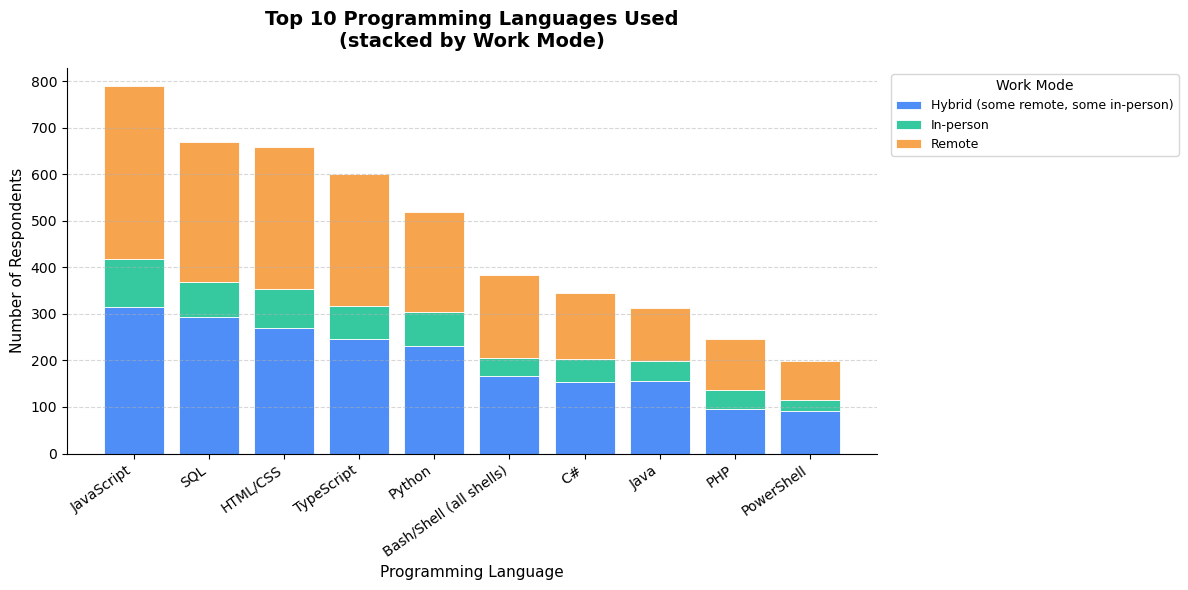

Chart saved.


In [2]:
# ── Prepare data ──────────────────────────────────────────────────────────────
lang_series = (df['LanguageHaveWorkedWith']
               .dropna()
               .str.split(';')
               .explode()
               .str.strip())

top10_langs = lang_series.value_counts().head(10).index.tolist()

# Count per language split by RemoteWork (stack dimension)
df_lang = df[['LanguageHaveWorkedWith', 'RemoteWork']].dropna()
df_lang = df_lang.assign(
    Language=df_lang['LanguageHaveWorkedWith'].str.split(';')
).explode('Language')
df_lang['Language'] = df_lang['Language'].str.strip()
df_lang = df_lang[df_lang['Language'].isin(top10_langs)]

pivot = (df_lang.groupby(['Language', 'RemoteWork'])
                .size()
                .unstack(fill_value=0)
                .loc[top10_langs])           # keep top-10 order

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#4f8ef7', '#36c9a0', '#f7a44f']
bottom = np.zeros(len(pivot))

for i, col in enumerate(pivot.columns):
    ax.bar(pivot.index, pivot[col], bottom=bottom,
           label=col, color=colors[i % len(colors)],
           edgecolor='white', linewidth=0.6)
    bottom += pivot[col].values

ax.set_title('Top 10 Programming Languages Used\n(stacked by Work Mode)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Programming Language', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_xticklabels(pivot.index, rotation=35, ha='right', fontsize=10)
ax.legend(title='Work Mode', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_top10_languages_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

C:\Users\Dennis\AppData\Local\Temp\ipykernel_12020\987842994.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(pivot_db.index, rotation=35, ha='right', fontsize=10)


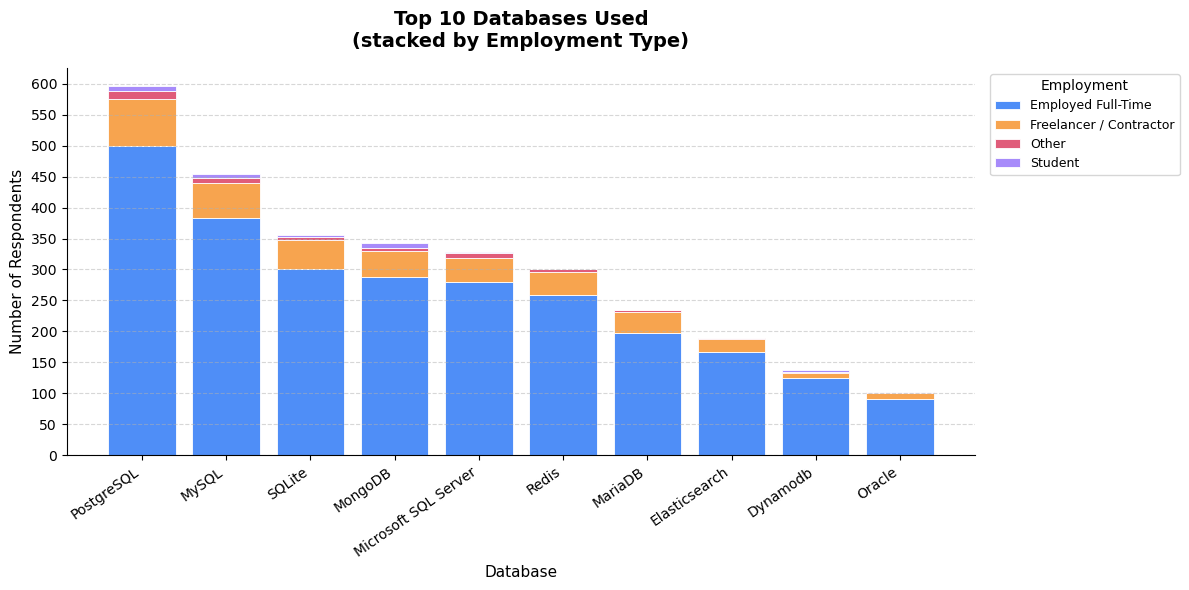

Chart saved.


In [3]:
# ── Prepare data ──────────────────────────────────────────────────────────────
db_series = (df['DatabaseHaveWorkedWith']
             .dropna()
             .str.split(';')
             .explode()
             .str.strip())

top10_dbs = db_series.value_counts().head(10).index.tolist()

df_db = df[['DatabaseHaveWorkedWith', 'Employment']].dropna()
df_db = df_db.assign(
    Database=df_db['DatabaseHaveWorkedWith'].str.split(';')
).explode('Database')
df_db['Database'] = df_db['Database'].str.strip()
df_db = df_db[df_db['Database'].isin(top10_dbs)]

# Simplify multi-value employment to primary status
def primary_employment(val):
    if 'full-time' in str(val).lower():
        return 'Employed Full-Time'
    elif 'student' in str(val).lower():
        return 'Student'
    elif 'freelancer' in str(val).lower() or 'contractor' in str(val).lower():
        return 'Freelancer / Contractor'
    else:
        return 'Other'

df_db['EmpGroup'] = df_db['Employment'].apply(primary_employment)

pivot_db = (df_db.groupby(['Database', 'EmpGroup'])
                 .size()
                 .unstack(fill_value=0)
                 .loc[top10_dbs])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors_db = ['#4f8ef7', '#f7a44f', '#e05c7a', '#a78bfa']
bottom = np.zeros(len(pivot_db))

for i, col in enumerate(pivot_db.columns):
    ax.bar(pivot_db.index, pivot_db[col], bottom=bottom,
           label=col, color=colors_db[i % len(colors_db)],
           edgecolor='white', linewidth=0.6)
    bottom += pivot_db[col].values

ax.set_title('Top 10 Databases Used\n(stacked by Employment Type)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Database', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_xticklabels(pivot_db.index, rotation=35, ha='right', fontsize=10)
ax.legend(title='Employment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_top10_databases_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

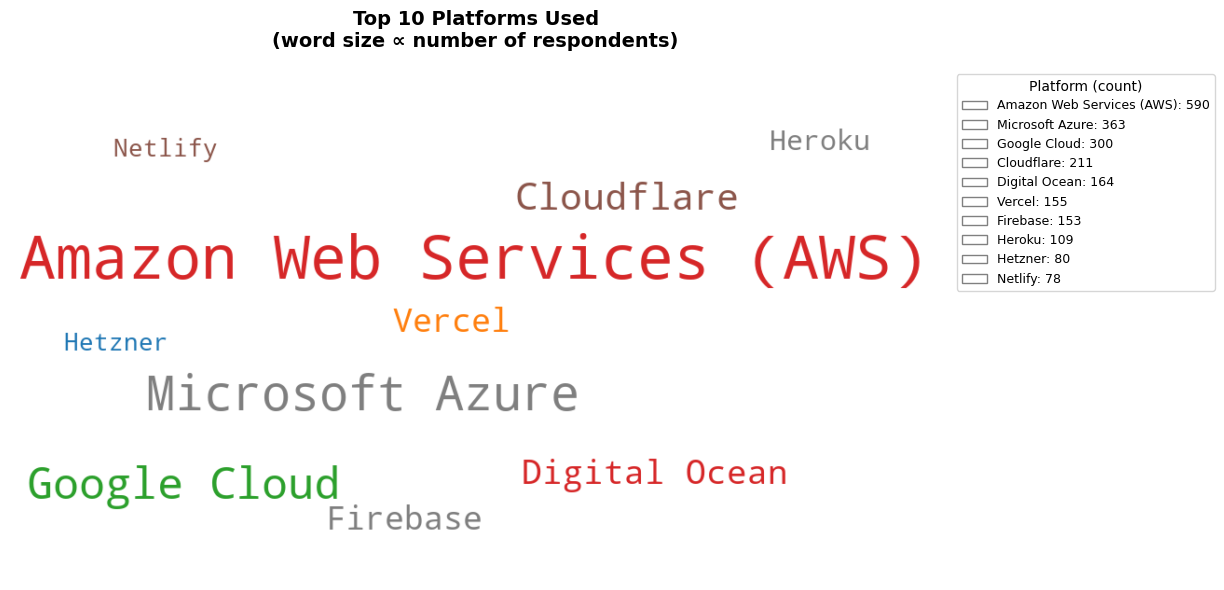

Chart saved.


In [4]:
# ── Prepare data ──────────────────────────────────────────────────────────────
platform_counts = (df['PlatformHaveWorkedWith']
                   .dropna()
                   .str.split(';')
                   .explode()
                   .str.strip()
                   .value_counts()
                   .head(10))

# Build frequency dict for WordCloud
freq_dict = platform_counts.to_dict()

# ── Plot ──────────────────────────────────────────────────────────────────────
wc = WordCloud(
    width            = 1000,
    height           = 550,
    background_color = 'white',
    colormap         = 'tab10',
    max_font_size    = 140,
    min_font_size    = 24,
    prefer_horizontal= 0.85,
    margin           = 12,
    collocations     = False
).generate_from_frequencies(freq_dict)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Top 10 Platforms Used\n(word size ∝ number of respondents)',
             fontsize=14, fontweight='bold', pad=15)

# Legend with actual counts
legend_labels = [f"{name}: {count}" for name, count in platform_counts.items()]
handles = [plt.Rectangle((0,0),1,1, color='white', ec='grey') for _ in legend_labels]
ax.legend(handles, legend_labels, title='Platform (count)',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('chart3_top10_platforms_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

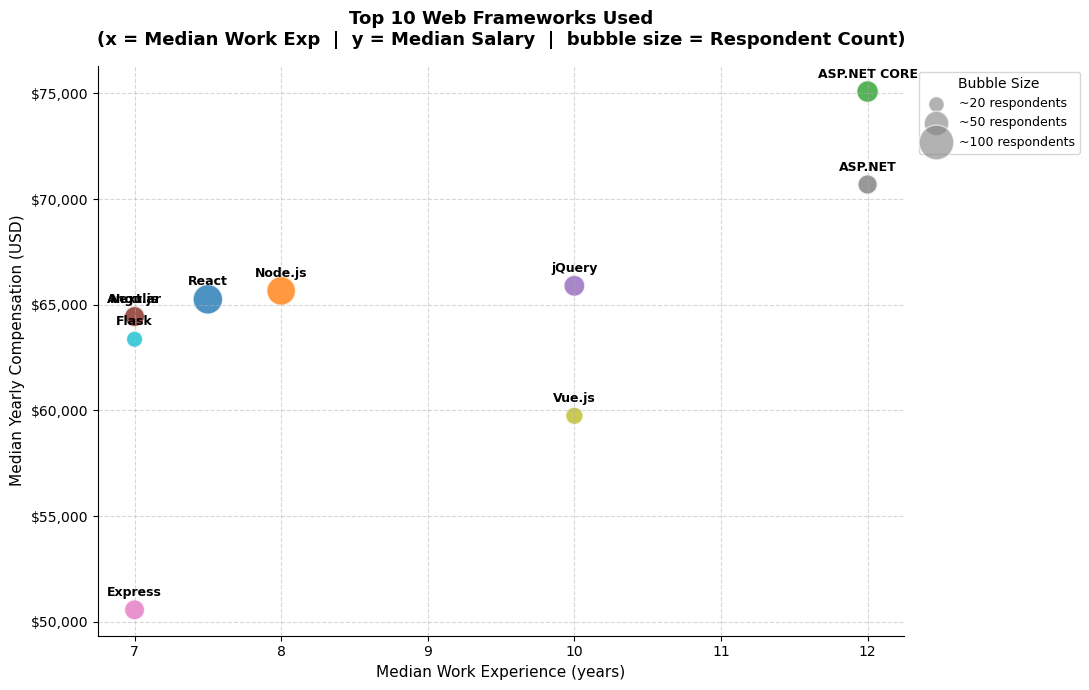

Chart saved.


In [5]:
# ── Prepare data ──────────────────────────────────────────────────────────────
wf_series = (df['WebframeHaveWorkedWith']
             .dropna()
             .str.split(';')
             .explode()
             .str.strip())

top10_wf = wf_series.value_counts().head(10)

df_wf = df[['WebframeHaveWorkedWith', 'ConvertedCompYearly', 'WorkExp']].dropna()
df_wf = df_wf.assign(
    Framework=df_wf['WebframeHaveWorkedWith'].str.split(';')
).explode('Framework')
df_wf['Framework'] = df_wf['Framework'].str.strip()
df_wf = df_wf[df_wf['Framework'].isin(top10_wf.index)]

# Aggregate: x = median work exp, y = median salary, bubble = respondent count
agg = df_wf.groupby('Framework').agg(
    MedianWorkExp  = ('WorkExp',              'median'),
    MedianSalary   = ('ConvertedCompYearly',  'median'),
    Count          = ('Framework',            'count')
).reset_index()
agg = agg.sort_values('Count', ascending=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

colors_wf = plt.cm.tab10(np.linspace(0, 1, len(agg)))
scatter = ax.scatter(
    agg['MedianWorkExp'],
    agg['MedianSalary'],
    s     = agg['Count'] * 2.5,         # bubble size ∝ respondent count
    c     = colors_wf,
    alpha = 0.80,
    edgecolors = 'white',
    linewidths = 1.2
)

# Label each bubble
for _, row in agg.iterrows():
    ax.annotate(
        row['Framework'],
        (row['MedianWorkExp'], row['MedianSalary']),
        textcoords = 'offset points',
        xytext     = (0, 10),
        ha         = 'center',
        fontsize   = 9,
        fontweight = 'bold'
    )

ax.set_title('Top 10 Web Frameworks Used\n(x = Median Work Exp  |  y = Median Salary  |  bubble size = Respondent Count)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Median Work Experience (years)', fontsize=11)
ax.set_ylabel('Median Yearly Compensation (USD)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

# Bubble size legend
for size_val, label in [(50, '~20'), (125, '~50'), (250, '~100')]:
    ax.scatter([], [], s=size_val * 2.5, c='grey', alpha=0.6,
               edgecolors='white', label=f'{label} respondents')
ax.legend(title='Bubble Size', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('chart4_top10_webframeworks_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### ---------------------

C:\Users\Dennis\AppData\Local\Temp\ipykernel_12020\3570881393.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(pivot_lw.index, rotation=35, ha='right', fontsize=10)


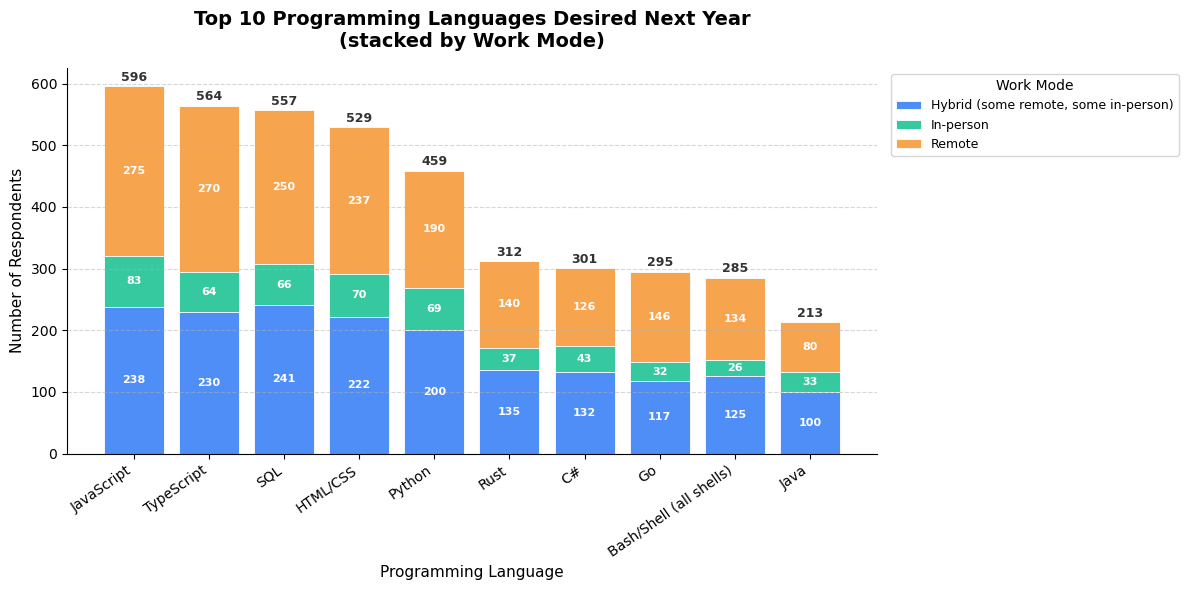

Chart saved.


In [6]:
# ── Prepare data ──────────────────────────────────────────────────────────────
lang_want = (df['LanguageWantToWorkWith']
             .dropna()
             .str.split(';')
             .explode()
             .str.strip())

top10_lang_want = lang_want.value_counts().head(10).index.tolist()

df_lw = df[['LanguageWantToWorkWith', 'RemoteWork']].dropna()
df_lw = df_lw.assign(
    Language=df_lw['LanguageWantToWorkWith'].str.split(';')
).explode('Language')
df_lw['Language'] = df_lw['Language'].str.strip()
df_lw = df_lw[df_lw['Language'].isin(top10_lang_want)]

pivot_lw = (df_lw.groupby(['Language', 'RemoteWork'])
                 .size()
                 .unstack(fill_value=0)
                 .loc[top10_lang_want])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#4f8ef7', '#36c9a0', '#f7a44f']
bottom = np.zeros(len(pivot_lw))

for i, col in enumerate(pivot_lw.columns):
    bars = ax.bar(pivot_lw.index, pivot_lw[col], bottom=bottom,
                  label=col, color=colors[i % len(colors)],
                  edgecolor='white', linewidth=0.6)
    # Add value labels inside each segment (only if tall enough)
    for bar, val in zip(bars, pivot_lw[col]):
        if val > 15:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(val), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += pivot_lw[col].values

# Total labels on top of each bar
for i, total in enumerate(pivot_lw.sum(axis=1)):
    ax.text(i, total + 4, str(int(total)),
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333')

ax.set_title('Top 10 Programming Languages Desired Next Year\n(stacked by Work Mode)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Programming Language', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_xticklabels(pivot_lw.index, rotation=35, ha='right', fontsize=10)
ax.legend(title='Work Mode', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('future_chart1_languages_desired.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

C:\Users\Dennis\AppData\Local\Temp\ipykernel_12020\3724709260.py:66: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(pivot_dw.index, rotation=35, ha='right', fontsize=10)


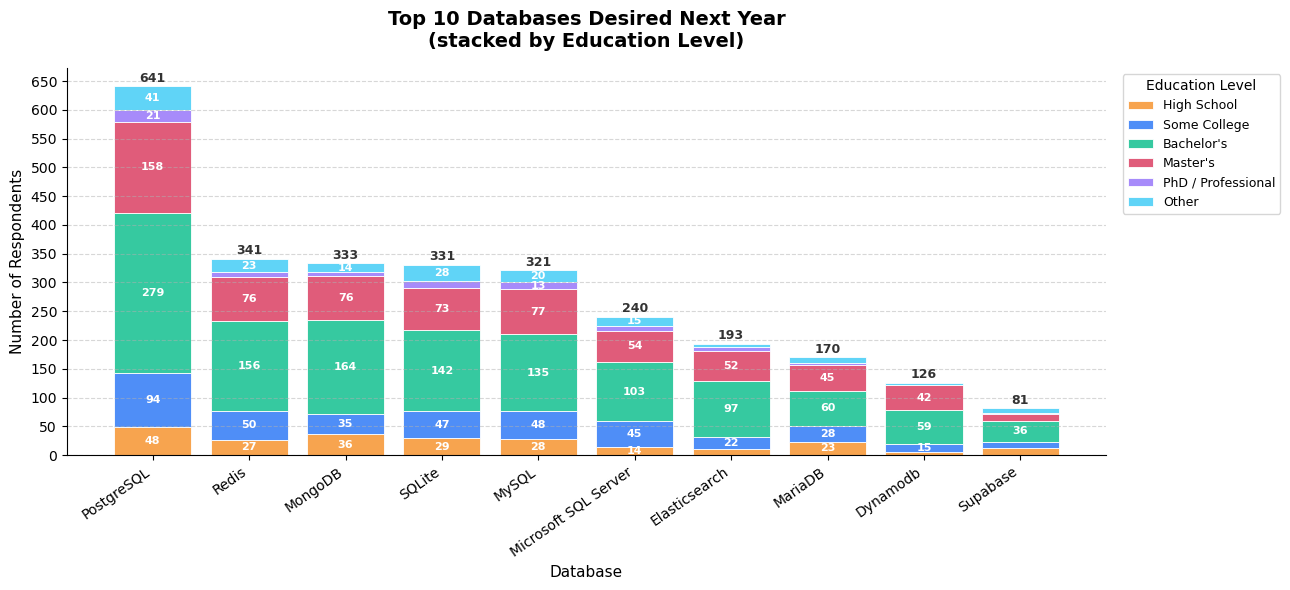

Chart saved.


In [7]:
# ── Prepare data ──────────────────────────────────────────────────────────────
db_want = (df['DatabaseWantToWorkWith']
           .dropna()
           .str.split(';')
           .explode()
           .str.strip())

top10_db_want = db_want.value_counts().head(10).index.tolist()

df_dw = df[['DatabaseWantToWorkWith', 'EdLevel']].dropna()
df_dw = df_dw.assign(
    Database=df_dw['DatabaseWantToWorkWith'].str.split(';')
).explode('Database')
df_dw['Database'] = df_dw['Database'].str.strip()
df_dw = df_dw[df_dw['Database'].isin(top10_db_want)]

# Simplify education levels
def simplify_ed(val):
    v = str(val)
    if "Bachelor" in v:   return "Bachelor's"
    if "Master"   in v:   return "Master's"
    if "doctoral" in v or "Ph.D" in v or "Professional" in v: return "PhD / Professional"
    if "secondary" in v.lower() or "high school" in v.lower(): return "High School"
    if "Some college" in v: return "Some College"
    return "Other"

df_dw['EdGroup'] = df_dw['EdLevel'].apply(simplify_ed)

ed_order = ["High School", "Some College", "Bachelor's", "Master's",
            "PhD / Professional", "Other"]
pivot_dw = (df_dw.groupby(['Database', 'EdGroup'])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(columns=[e for e in ed_order
                                   if e in df_dw['EdGroup'].unique()],
                          fill_value=0)
                 .loc[top10_db_want])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

colors_db = ['#f7a44f', '#4f8ef7', '#36c9a0', '#e05c7a', '#a78bfa', '#60d4f7']
bottom = np.zeros(len(pivot_dw))

for i, col in enumerate(pivot_dw.columns):
    bars = ax.bar(pivot_dw.index, pivot_dw[col], bottom=bottom,
                  label=col, color=colors_db[i % len(colors_db)],
                  edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, pivot_dw[col]):
        if val > 12:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(val), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += pivot_dw[col].values

# Total labels
for i, total in enumerate(pivot_dw.sum(axis=1)):
    ax.text(i, total + 3, str(int(total)),
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333')

ax.set_title('Top 10 Databases Desired Next Year\n(stacked by Education Level)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Database', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_xticklabels(pivot_dw.index, rotation=35, ha='right', fontsize=10)
ax.legend(title='Education Level', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('future_chart2_databases_desired.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

C:\Users\Dennis\AppData\Local\Temp\ipykernel_12020\475193291.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap   = plt.cm.get_cmap('Blues', len(sizes) + 3)


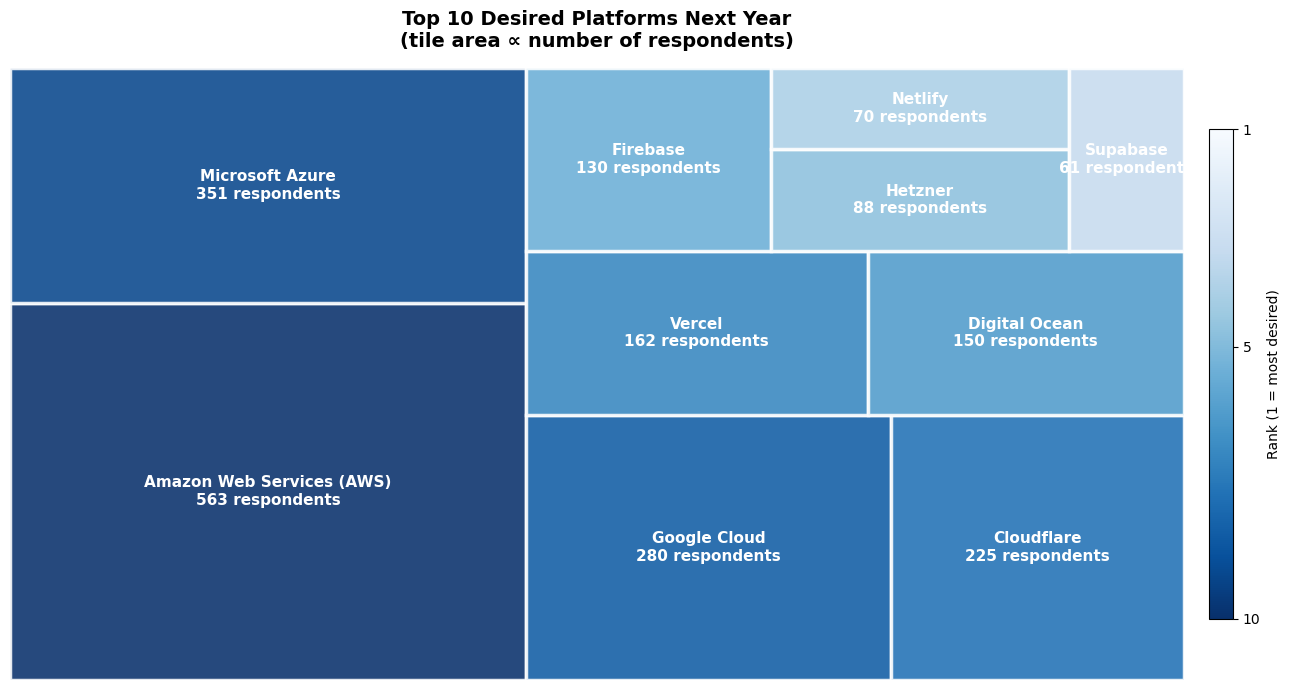

Chart saved.


In [8]:
# ── Prepare data ──────────────────────────────────────────────────────────────
plat_want = (df['PlatformWantToWorkWith']
             .dropna()
             .str.split(';')
             .explode()
             .str.strip()
             .value_counts()
             .head(10))

labels = [f"{name}\n{count} respondents"
          for name, count in plat_want.items()]

sizes  = plat_want.values.tolist()

# Color gradient from deep blue → teal based on rank
cmap   = plt.cm.get_cmap('Blues', len(sizes) + 3)
colors = [cmap(len(sizes) + 2 - i) for i in range(len(sizes))]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_facecolor('#f0f4f8')

squarify.plot(
    sizes      = sizes,
    label      = labels,
    color      = colors,
    alpha      = 0.88,
    edgecolor  = 'white',
    linewidth  = 2.5,
    text_kwargs= {'fontsize': 11, 'fontweight': 'bold', 'color': 'white',
                  'wrap': True},
    ax         = ax
)

ax.set_title('Top 10 Desired Platforms Next Year\n(tile area ∝ number of respondents)',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

# Colour-scale legend (rank 1 → rank 10)
sm = plt.cm.ScalarMappable(cmap='Blues',
                            norm=plt.Normalize(vmin=1, vmax=10))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                    fraction=0.02, pad=0.02)
cbar.set_label('Rank (1 = most desired)', fontsize=10)
cbar.set_ticks([1, 5, 10])
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.savefig('future_chart3_platforms_treemap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

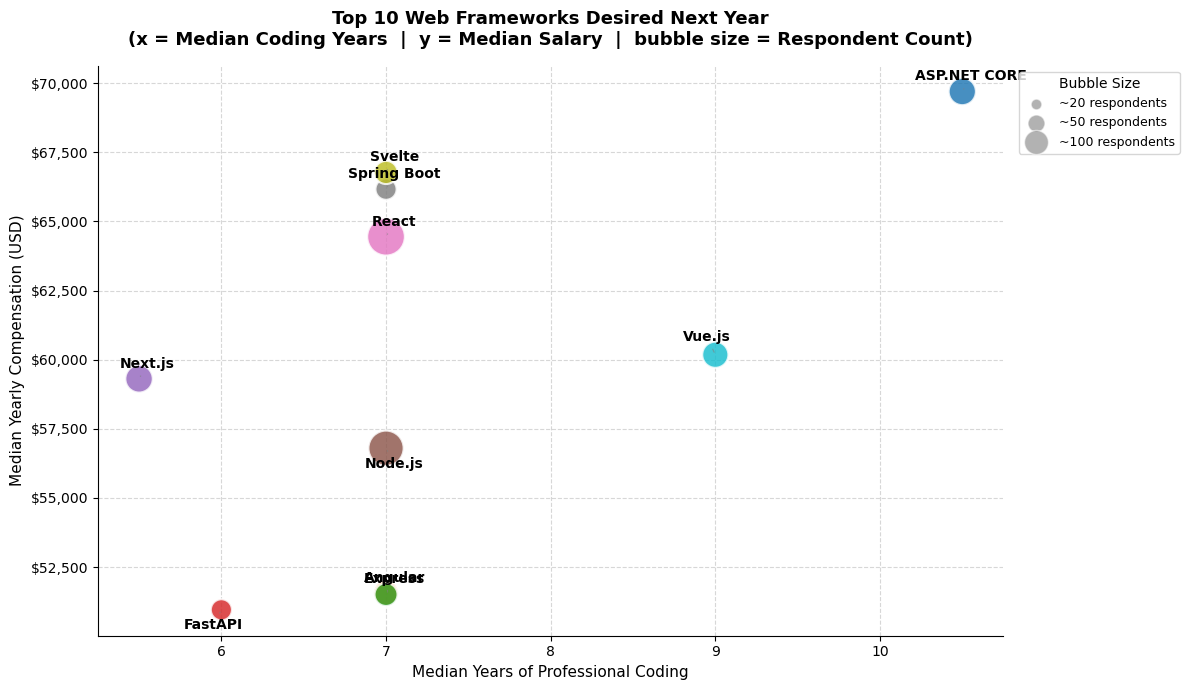

Chart saved.


In [9]:
# ── Prepare data ──────────────────────────────────────────────────────────────
wf_want = (df['WebframeWantToWorkWith']
           .dropna()
           .str.split(';')
           .explode()
           .str.strip())

top10_wf_want = wf_want.value_counts().head(10).index.tolist()

df_wfw = df[['WebframeWantToWorkWith',
             'ConvertedCompYearly',
             'YearsCodePro']].dropna()
df_wfw = df_wfw.assign(
    Framework=df_wfw['WebframeWantToWorkWith'].str.split(';')
).explode('Framework')
df_wfw['Framework'] = df_wfw['Framework'].str.strip()
df_wfw = df_wfw[df_wfw['Framework'].isin(top10_wf_want)]

# YearsCodePro has text values — convert to numeric
def parse_years(v):
    if pd.isna(v):             return np.nan
    if 'Less than 1' in str(v): return 0.5
    if 'More than 50' in str(v): return 51
    try:   return float(v)
    except: return np.nan

df_wfw['YearsNum'] = df_wfw['YearsCodePro'].apply(parse_years)

agg_wfw = df_wfw.groupby('Framework').agg(
    MedianYears  = ('YearsNum',             'median'),
    MedianSalary = ('ConvertedCompYearly',  'median'),
    Count        = ('Framework',            'count')
).reset_index()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

colors_wfw = plt.cm.tab10(np.linspace(0, 1, len(agg_wfw)))

sc = ax.scatter(
    agg_wfw['MedianYears'],
    agg_wfw['MedianSalary'],
    s          = agg_wfw['Count'] * 3,
    c          = colors_wfw,
    alpha      = 0.82,
    edgecolors = 'white',
    linewidths = 1.5,
    zorder     = 3
)

# Framework labels — offset to avoid overlap
offsets = {
    'React'     : (6,  8),  'Node.js'    : (6, -14),
    'Vue.js'    : (-6, 10), 'Angular'    : (6,  8),
    'Next.js'   : (6,  8),  'FastAPI'    : (-6, -14),
    'Django'    : (6,  8),  'ASP.NET'    : (6, -14),
    'Spring'    : (-6, 10), 'Express'    : (6,  8),
}
for _, row in agg_wfw.iterrows():
    ox, oy = offsets.get(row['Framework'], (6, 8))
    ax.annotate(
        row['Framework'],
        (row['MedianYears'], row['MedianSalary']),
        textcoords='offset points', xytext=(ox, oy),
        ha='center', fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='grey',
                        lw=0.8, alpha=0.6)
    )

ax.set_title('Top 10 Web Frameworks Desired Next Year\n'
             '(x = Median Coding Years  |  y = Median Salary  |  bubble size = Respondent Count)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Median Years of Professional Coding', fontsize=11)
ax.set_ylabel('Median Yearly Compensation (USD)',    fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

# Bubble size legend
for n_resp, lbl in [(20, '~20 respondents'),
                    (50, '~50 respondents'),
                    (100,'~100 respondents')]:
    ax.scatter([], [], s=n_resp * 3, c='grey', alpha=0.6,
               edgecolors='white', label=lbl)
ax.legend(title='Bubble Size', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('future_chart4_webframeworks_desired.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### ----------------------

In [10]:
# ── Shared education simplifier (reused across charts) ────────────────────────
def simplify_ed(val):
    v = str(val)
    if 'Bachelor'                         in v: return "Bachelor's"
    if 'Master'                           in v: return "Master's"
    if 'Ph.D' in v or 'Professional'     in v: return "PhD / Professional"
    if 'Associate'                        in v: return "Associate"
    if 'Some college'                     in v: return "Some College"
    if 'secondary' in v.lower() or 'high school' in v.lower(): return "High School"
    if 'Primary'                          in v: return "Primary School"
    return "Other"

ed_order = ["Primary School", "High School", "Some College", "Associate",
            "Bachelor's", "Master's", "PhD / Professional", "Other"]

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old',    '45-54 years old', '55-64 years old',
             '65 years or older']

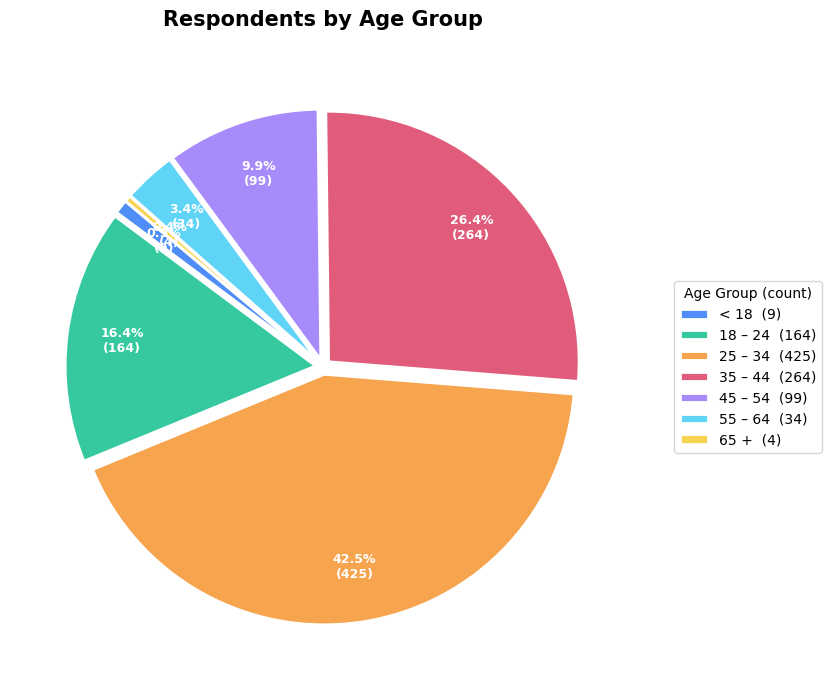

Chart saved.


In [11]:
# ── Prepare data ──────────────────────────────────────────────────────────────
age_counts = (df['Age']
              .value_counts()
              .reindex([a for a in age_order if a in df['Age'].values]))

short_labels = {
    'Under 18 years old' : '< 18',
    '18-24 years old'    : '18 – 24',
    '25-34 years old'    : '25 – 34',
    '35-44 years old'    : '35 – 44',
    '45-54 years old'    : '45 – 54',
    '55-64 years old'    : '55 – 64',
    '65 years or older'  : '65 +',
}
labels  = [short_labels[a] for a in age_counts.index]
sizes   = age_counts.values
colors  = ['#4f8ef7','#36c9a0','#f7a44f','#e05c7a',
           '#a78bfa','#60d4f7','#f7d44f']
explode = [0.03] * len(sizes)          # slight separation on all slices

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels     = None,
    autopct    = lambda p: f'{p:.1f}%\n({int(round(p * sum(sizes) / 100))})',
    startangle = 140,
    colors     = colors,
    explode    = explode,
    pctdistance= 0.78,
    wedgeprops = dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Respondents by Age Group', fontsize=15,
             fontweight='bold', pad=20)

# Legend outside
ax.legend(wedges, [f"{l}  ({s})" for l, s in zip(labels, sizes)],
          title='Age Group (count)', title_fontsize=10,
          bbox_to_anchor=(1.05, 0.5), loc='center left',
          fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig('demo_chart1_age_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

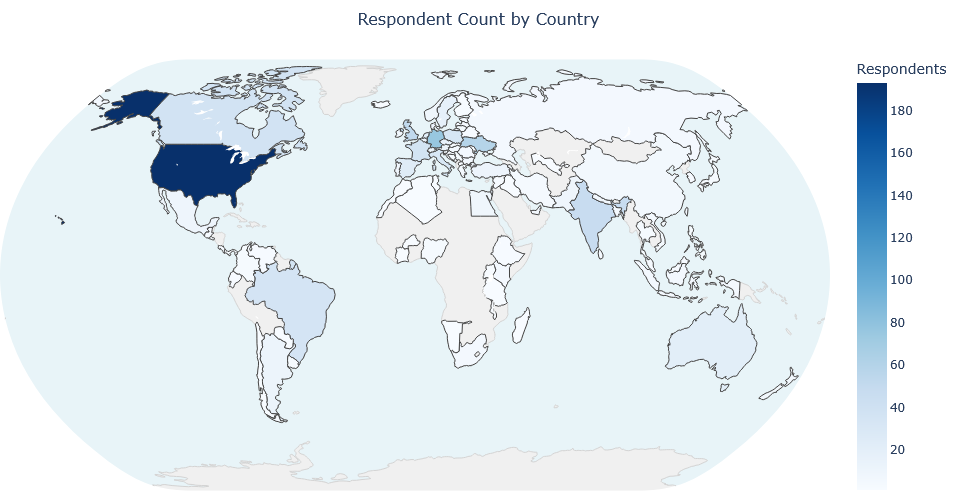

Map chart saved as HTML.


In [12]:
# ── Prepare data ──────────────────────────────────────────────────────────────
# Standardise a few long country names so Plotly can match them to ISO codes
country_rename = {
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United States of America'                            : 'United States',
    'Iran, Islamic Republic of...'                        : 'Iran',
    'Viet Nam'                                            : 'Vietnam',
    'Russian Federation'                                  : 'Russia',
    'Bolivia, Plurinational State of...'                  : 'Bolivia',
    "Korea, Republic of"                                  : 'South Korea',
    "Democratic People's Republic of Korea"               : 'North Korea',
    'Taiwan, Province of China...'                        : 'Taiwan',
    'Hong Kong (S.A.R.)'                                  : 'Hong Kong',
    'Republic of Moldova'                                 : 'Moldova',
    'Syrian Arab Republic'                                : 'Syria',
}

country_counts = (df['Country']
                  .replace(country_rename)
                  .value_counts()
                  .reset_index())
country_counts.columns = ['Country', 'Respondents']

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_map = px.choropleth(
    country_counts,
    locations        = 'Country',
    locationmode     = 'country names',
    color            = 'Respondents',
    hover_name       = 'Country',
    color_continuous_scale = px.colors.sequential.Blues,
    title            = 'Respondent Count by Country',
)
fig_map.update_layout(
    title_font_size  = 16,
    title_x          = 0.5,
    geo=dict(
        showframe      = False,
        showcoastlines = True,
        coastlinecolor = 'lightgrey',
        showland       = True,
        landcolor      = '#f0f0f0',
        showocean      = True,
        oceancolor     = '#e8f4f8',
        projection_type= 'natural earth'
    ),
    coloraxis_colorbar=dict(
        title      = 'Respondents',
        tickformat = 'd'
    ),
    margin = dict(l=0, r=0, t=50, b=0),
    height = 500,
)
fig_map.write_html('demo_chart2_country_map.html')
fig_map.show()
print("Map chart saved as HTML.")

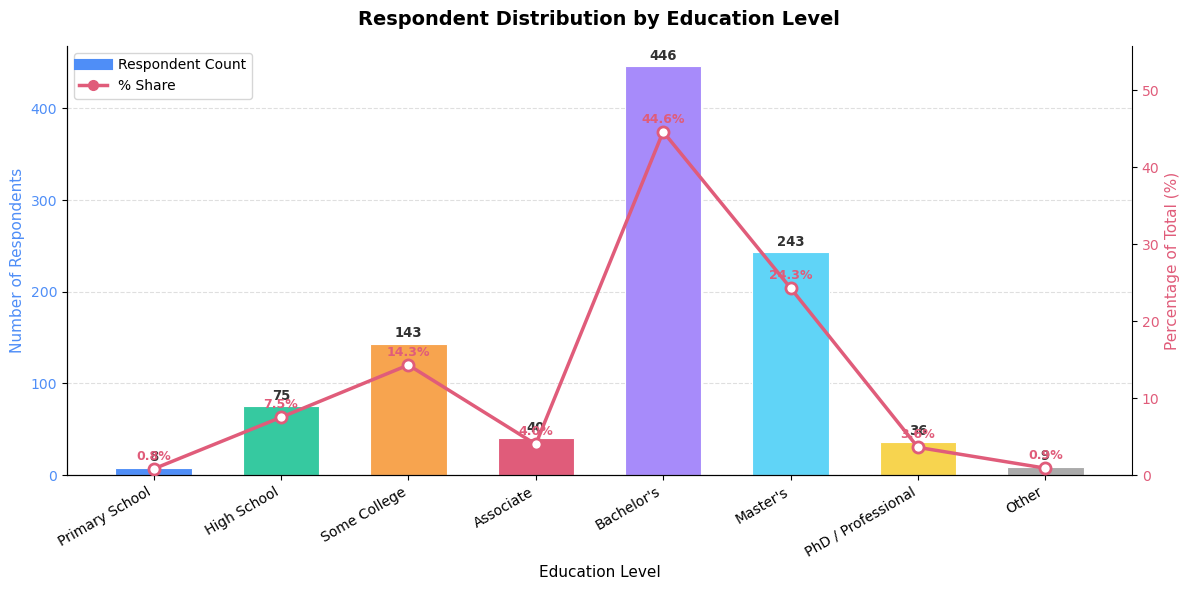

Chart saved.


In [13]:
# ── Prepare data ──────────────────────────────────────────────────────────────
df['EdGroup'] = df['EdLevel'].apply(simplify_ed)

ed_counts = (df['EdGroup']
             .value_counts()
             .reindex([e for e in ed_order if e in df['EdGroup'].values]))

pct = (ed_counts / ed_counts.sum() * 100).round(1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()                       # second y-axis for the line

bar_colors = ['#4f8ef7','#36c9a0','#f7a44f','#e05c7a',
              '#a78bfa','#60d4f7','#f7d44f','#aaaaaa']

x = np.arange(len(ed_counts))

# Bars — raw counts
bars = ax1.bar(x, ed_counts.values,
               color=bar_colors[:len(ed_counts)],
               edgecolor='white', linewidth=0.8,
               width=0.6, label='Respondent Count', zorder=2)

# Count labels above bars
for bar, val in zip(bars, ed_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 4,
             str(val), ha='center', va='bottom',
             fontsize=9.5, fontweight='bold', color='#333')

# Line — percentage
ax2.plot(x, pct.values,
         color='#e05c7a', linewidth=2.5,
         marker='o', markersize=8,
         markerfacecolor='white', markeredgewidth=2,
         label='% Share', zorder=3)

# Percentage labels above markers
for xi, yi in zip(x, pct.values):
    ax2.text(xi, yi + 0.8, f'{yi}%',
             ha='center', va='bottom',
             fontsize=9, color='#e05c7a', fontweight='bold')

ax1.set_title('Respondent Distribution by Education Level',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Education Level', fontsize=11)
ax1.set_ylabel('Number of Respondents', fontsize=11, color='#4f8ef7')
ax2.set_ylabel('Percentage of Total (%)', fontsize=11, color='#e05c7a')
ax1.set_xticks(x)
ax1.set_xticklabels(ed_counts.index, rotation=30, ha='right', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#4f8ef7')
ax2.tick_params(axis='y', labelcolor='#e05c7a')
ax2.set_ylim(0, pct.max() * 1.25)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# Combined legend
bar_patch  = mlines.Line2D([], [], color='#4f8ef7', linewidth=8,
                            label='Respondent Count')
line_patch = mlines.Line2D([], [], color='#e05c7a', linewidth=2.5,
                            marker='o', markersize=7, label='% Share')
ax1.legend(handles=[bar_patch, line_patch],
           loc='upper left', fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig('demo_chart3_education_linebar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

C:\Users\Dennis\AppData\Local\Temp\ipykernel_12020\193581101.py:67: UserWarning:

FixedFormatter should only be used together with FixedLocator



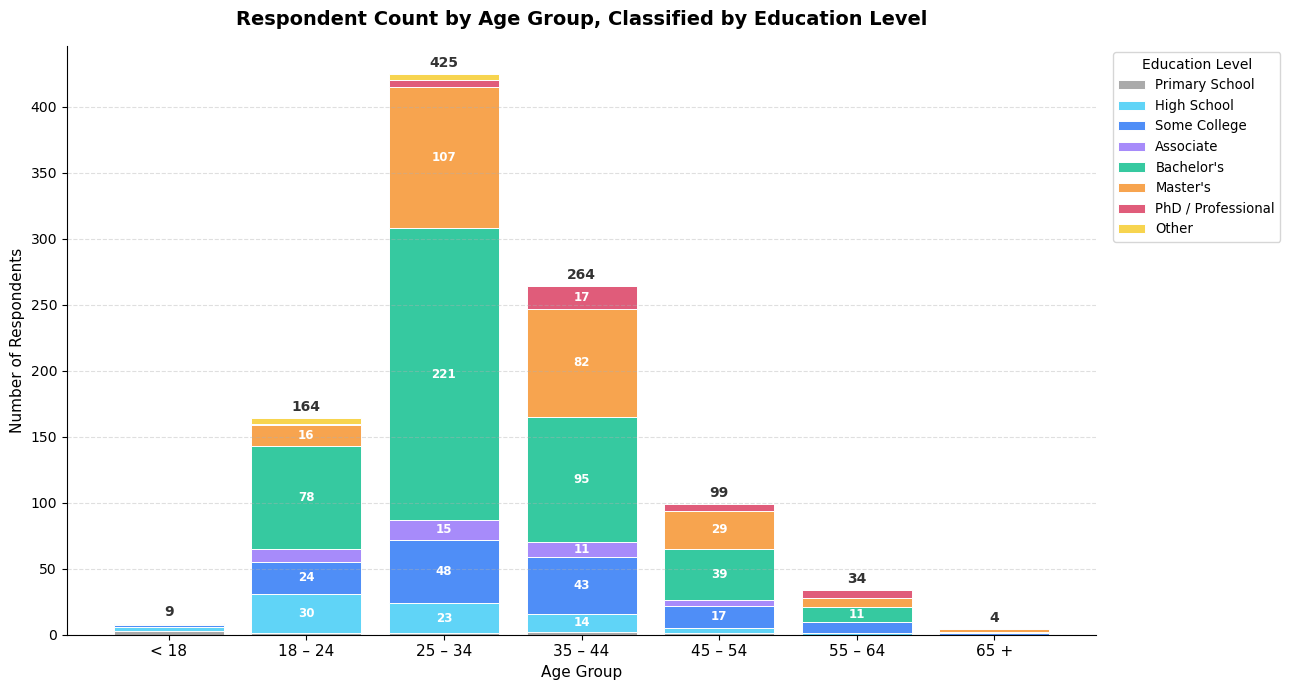

Chart saved.


In [14]:
# ── Prepare data ──────────────────────────────────────────────────────────────
df['EdGroup'] = df['EdLevel'].apply(simplify_ed)
df_ae = df[['Age', 'EdGroup']].dropna()
df_ae = df_ae[df_ae['Age'].isin(age_order)]

pivot_ae = (df_ae.groupby(['Age', 'EdGroup'])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(index=[a for a in age_order
                                 if a in df_ae['Age'].values])
                 .reindex(columns=[e for e in ed_order
                                   if e in df_ae['EdGroup'].values],
                          fill_value=0))

short_age = {
    'Under 18 years old' : '< 18',
    '18-24 years old'    : '18 – 24',
    '25-34 years old'    : '25 – 34',
    '35-44 years old'    : '35 – 44',
    '45-54 years old'    : '45 – 54',
    '55-64 years old'    : '55 – 64',
    '65 years or older'  : '65 +',
}
pivot_ae.index = [short_age.get(a, a) for a in pivot_ae.index]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

ed_colors = {
    "Primary School"      : '#aaaaaa',
    "High School"         : '#60d4f7',
    "Some College"        : '#4f8ef7',
    "Associate"           : '#a78bfa',
    "Bachelor's"          : '#36c9a0',
    "Master's"            : '#f7a44f',
    "PhD / Professional"  : '#e05c7a',
    "Other"               : '#f7d44f',
}

bottom = np.zeros(len(pivot_ae))

for ed_level in pivot_ae.columns:
    vals  = pivot_ae[ed_level].values
    color = ed_colors.get(ed_level, '#cccccc')
    bars  = ax.bar(pivot_ae.index, vals, bottom=bottom,
                   label=ed_level, color=color,
                   edgecolor='white', linewidth=0.7)
    # Value labels inside segments (only if tall enough)
    for bar, val in zip(bars, vals):
        if val > 10:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(int(val)), ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottom += vals

# Total labels on top
for i, total in enumerate(pivot_ae.sum(axis=1)):
    ax.text(i, total + 3, str(int(total)),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333')

ax.set_title('Respondent Count by Age Group, Classified by Education Level',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_xticklabels(pivot_ae.index, fontsize=11)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Education Level',
          bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9.5, frameon=True)

plt.tight_layout()
plt.savefig('demo_chart4_age_x_education_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")